# Imports

In [ ]:
#!pip install thop torchinfo
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
from sklearn.metrics import f1_score
from thop import profile
from torchinfo import summary
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

# Loading and preprocessing data

In [21]:
# Define transformation to normalize images to [0,1]
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize to range [0,1]
])

# Load MNIST dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader for batching
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)

# Function to one-hot encode labels
def one_hot_encode(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()

The below code-block includes basic data visualizations

Images shape: torch.Size([32, 1, 28, 28])
Labels shape (one-hot): torch.Size([32, 10])


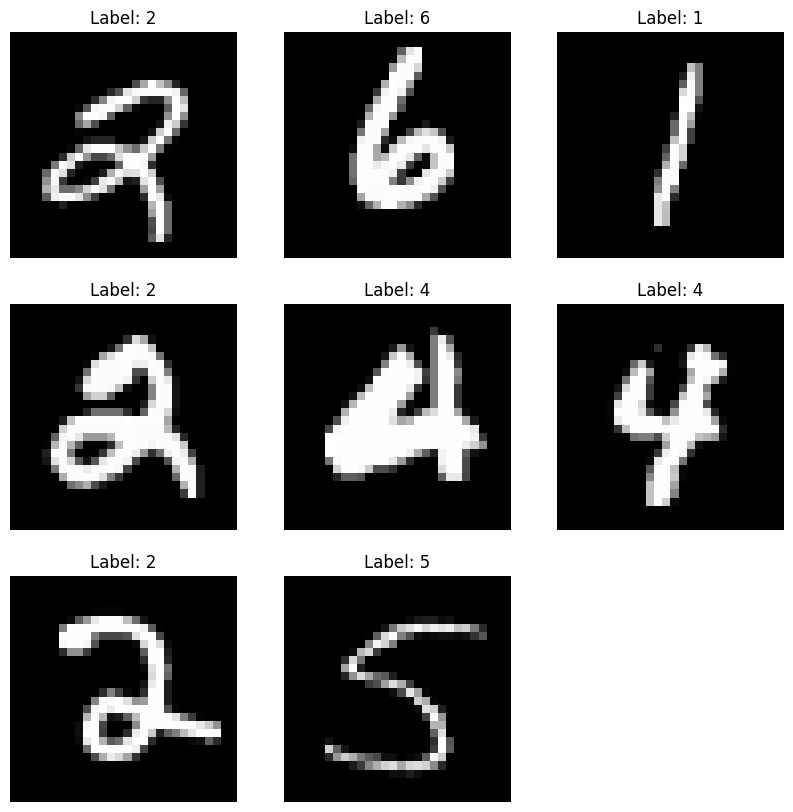

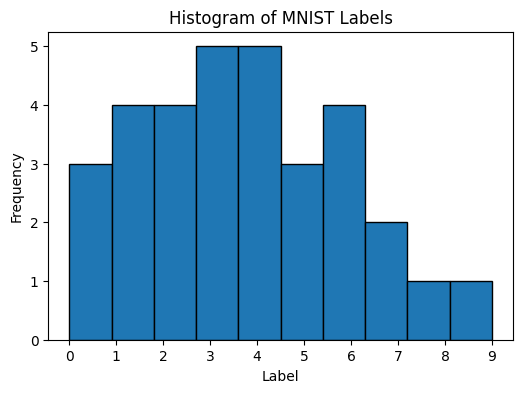

In [22]:
# Example of preprocessing a batch
images, labels = next(iter(train_loader))
labels_one_hot = one_hot_encode(labels)

print("Images shape:", images.shape)  # Should be [batch_size, 1, 28, 28]
print("Labels shape (one-hot):", labels_one_hot.shape)  # Should be [batch_size, 10]

# Function to plot a batch of images
def plot_images(images, labels, num_images=8):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f"Label: {labels[i].item()}")
        ax.axis('off')
    plt.show()

# Plot a batch of images with their labels
plot_images(images, labels)

# Plot histogram of labels
plt.figure(figsize=(6, 4))
plt.hist(labels.numpy(), bins=10, edgecolor='black')
plt.title('Histogram of MNIST Labels')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.xticks(range(10))
plt.show()

# Creation of Neural Network

In [57]:
class DeepNeuralNet(nn.Module):
    def __init__(self, layer_1_units=32, layer_2_units=10, dropout_rate=0.2):
        super(DeepNeuralNet, self).__init__()

        self.fc1 = nn.Linear(28 * 28, layer_1_units)  # Flattened MNIST input (28x28 -> 784)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.hid_1 = nn.Linear(layer_1_units, 128)
        self.hid_2 = nn.Linear(128, 64)
        self.dropout_2 = nn.Dropout(dropout_rate)
        self.hid_3 = nn.Linear(64, 32)
        self.dropout_3 = nn.Dropout(dropout_rate)
        #self.batch_1 = nn.BatchNorm2d(24)
        self.fc2 = nn.Linear(32, layer_2_units)  # Output layer (10 classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten input
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.hid_1(x))
        x = torch.relu(self.hid_2(x))
        x = self.dropout_2(x)
        x = torch.relu(self.hid_3(x))
        x = self.dropout_3(x)
        #x = self.batch_1(x)
        x = self.fc2(x)  # No softmax here (handled in loss function)
        return x

In [58]:
def create_model(layer_1_units=32, layer_2_units=10, learning_rate=0.001, dropout_rate=0.2):
    model = DeepNeuralNet(layer_1_units, layer_2_units, dropout_rate)

    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()  # Softmax is included in CrossEntropyLoss
    #optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    return model, criterion, optimizer


In [59]:
model, criterion, optimizer = create_model()

# Print model summary
print(model)

DeepNeuralNet(
  (fc1): Linear(in_features=784, out_features=32, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (hid_1): Linear(in_features=32, out_features=128, bias=True)
  (hid_2): Linear(in_features=128, out_features=64, bias=True)
  (dropout_2): Dropout(p=0.2, inplace=False)
  (hid_3): Linear(in_features=64, out_features=32, bias=True)
  (dropout_3): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=32, out_features=10, bias=True)
)


This code is important, here the model is measured BEFORE being trained.

In [60]:
input_tensor = torch.randn(1, 784)

# Provide an example input tensor of the same size as your test data
flops, params = profile(model, inputs=(input_tensor,))
macs = flops / 2  # Since 1 MAC = 2 FLOPs

print(f"MACs: {macs / 1e6:.3f} MMACs, GFLOPs: {flops / 1e9:.3f}, Parameters: {params / 1e6:.3f} M")

# Provide the shape of the input tensor as a tuple, not the tensor itself
summary(model, input_size=(1, 784))

[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
MACs: 0.020 MMACs, GFLOPs: 0.000, Parameters: 0.040 M


Layer (type:depth-idx)                   Output Shape              Param #
DeepNeuralNet                            [1, 10]                   --
├─Linear: 1-1                            [1, 32]                   25,120
├─ReLU: 1-2                              [1, 32]                   --
├─Dropout: 1-3                           [1, 32]                   --
├─Linear: 1-4                            [1, 128]                  4,224
├─Linear: 1-5                            [1, 64]                   8,256
├─Dropout: 1-6                           [1, 64]                   --
├─Linear: 1-7                            [1, 32]                   2,080
├─Dropout: 1-8                           [1, 32]                   --
├─Linear: 1-9                            [1, 10]                   330
Total params: 40,010
Trainable params: 40,010
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.04
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.16
Estimated Total Si

# Model Training and Testing Functions

In [46]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=5, device="cpu"):
    model.to(device)  # Move model to the specified device (CPU/GPU)

    # Lists to store the loss and accuracy values
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to device

            optimizer.zero_grad()  # Reset gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update weights

            running_loss += loss.item()
            _, predicted = outputs.max(1)  # Get class with highest probability
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Training metrics for the epoch
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation phase
        model.eval()  # Set model to evaluation mode
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():  # No gradients needed for validation
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        # Validation metrics for the epoch
        val_epoch_loss = val_loss / len(test_loader)
        val_epoch_acc = 100 * val_correct / val_total
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)

        # Print epoch metrics
        print(f"Epoch {epoch+1}/{num_epochs}, "
              f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.2f}%, "
              f"Val Loss: {val_epoch_loss:.4f}, Val Accuracy: {val_epoch_acc:.2f}%")

    # Return the lists of loss and accuracy for both training and validation
    return train_losses, train_accuracies, val_losses, val_accuracies


In [28]:
def test_model(model, test_loader, device="cpu"):
    model.to(device)  # Move model to the specified device (CPU/GPU)
    model.eval()  # Set model to evaluation mode

    all_labels = []
    all_preds = []
    correct = 0
    total = 0
    test_loss = 0.0
    criterion = nn.CrossEntropyLoss()  # Define loss function

    with torch.no_grad():  # No gradients needed for testing
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())  # Store true labels
            all_preds.extend(predicted.cpu().numpy())  # Store predicted labels

    # Calculate final accuracy
    accuracy = 100 * correct / total

    # Calculate F1 Score
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # Average test loss
    avg_test_loss = test_loss / len(test_loader)

    print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {accuracy:.2f}%, F1 Score: {f1:.4f}")

    return accuracy, avg_test_loss, f1

In [29]:
def plot_training_vs_validation(train_losses, val_losses, train_accuracies, val_accuracies):
    # Plot training and validation loss
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title('Training vs Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Model Training and Testing

In [61]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available
model, criterion, optimizer = create_model()
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, train_loader, test_loader, criterion, optimizer, num_epochs=20, device=device
)

Epoch 1/20, Train Loss: 0.7296, Train Accuracy: 76.20%, Val Loss: 0.3069, Val Accuracy: 90.97%
Epoch 2/20, Train Loss: 0.4508, Train Accuracy: 86.72%, Val Loss: 0.2494, Val Accuracy: 92.67%
Epoch 3/20, Train Loss: 0.3919, Train Accuracy: 88.57%, Val Loss: 0.2343, Val Accuracy: 92.71%
Epoch 4/20, Train Loss: 0.3652, Train Accuracy: 89.42%, Val Loss: 0.1984, Val Accuracy: 94.00%
Epoch 5/20, Train Loss: 0.3453, Train Accuracy: 89.96%, Val Loss: 0.1908, Val Accuracy: 94.38%
Epoch 6/20, Train Loss: 0.3316, Train Accuracy: 90.48%, Val Loss: 0.2016, Val Accuracy: 93.97%
Epoch 7/20, Train Loss: 0.3236, Train Accuracy: 90.49%, Val Loss: 0.2124, Val Accuracy: 93.35%
Epoch 8/20, Train Loss: 0.3118, Train Accuracy: 90.86%, Val Loss: 0.1732, Val Accuracy: 94.91%
Epoch 9/20, Train Loss: 0.2995, Train Accuracy: 91.23%, Val Loss: 0.1835, Val Accuracy: 94.79%
Epoch 10/20, Train Loss: 0.2940, Train Accuracy: 91.43%, Val Loss: 0.1714, Val Accuracy: 95.06%
Epoch 11/20, Train Loss: 0.2906, Train Accuracy: 

Test Loss: 0.1605, Test Accuracy: 94.96%, F1 Score: 0.9495


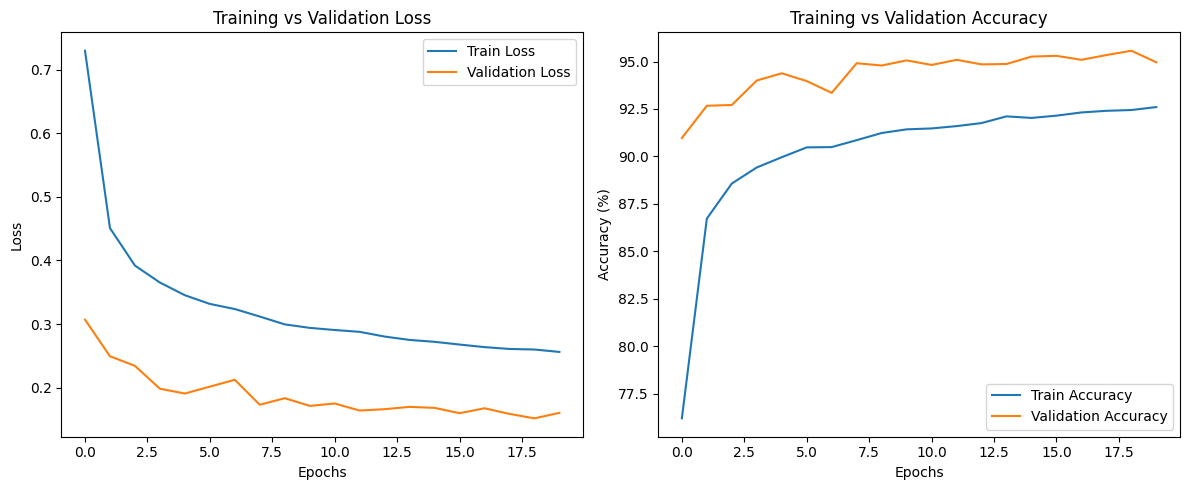

In [62]:
# Test the model and calculate F1 score
accuracy, avg_test_loss, f1 = test_model(model, test_loader, device=device)

# Plot the training vs validation metrics
plot_training_vs_validation(train_losses, val_losses, train_accuracies, val_accuracies)
